96 48
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


92/92 - 2s - 18ms/step - loss: 0.0588
Epoch 2/100
92/92 - 0s - 3ms/step - loss: 0.0248
Epoch 3/100
92/92 - 0s - 3ms/step - loss: 0.0199
Epoch 4/100
92/92 - 0s - 3ms/step - loss: 0.0179
Epoch 5/100
92/92 - 0s - 3ms/step - loss: 0.0162
Epoch 6/100
92/92 - 0s - 3ms/step - loss: 0.0147
Epoch 7/100
92/92 - 0s - 3ms/step - loss: 0.0132
Epoch 8/100
92/92 - 0s - 3ms/step - loss: 0.0118
Epoch 9/100
92/92 - 0s - 3ms/step - loss: 0.0105
Epoch 10/100
92/92 - 0s - 3ms/step - loss: 0.0093
Epoch 11/100
92/92 - 0s - 3ms/step - loss: 0.0082
Epoch 12/100
92/92 - 0s - 3ms/step - loss: 0.0072
Epoch 13/100
92/92 - 0s - 3ms/step - loss: 0.0064
Epoch 14/100
92/92 - 0s - 3ms/step - loss: 0.0058
Epoch 15/100
92/92 - 0s - 3ms/step - loss: 0.0053
Epoch 16/100
92/92 - 0s - 3ms/step - loss: 0.0049
Epoch 17/100
92/92 - 0s - 3ms/step - loss: 0.0047
Epoch 18/100
92/92 - 0s - 3ms/step - loss: 0.0045
Epoch 19/100
92/92 - 0s - 3ms/step - loss: 0.0044
Epoch 20/100
92/92 - 0s - 3ms/step - loss: 0.0044
Epoch 21/100
92/92 -

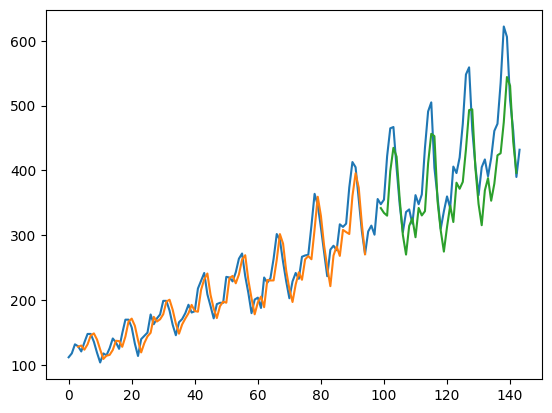

In [6]:
import pandas
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

tf.random.set_seed(7)

dataframe = pandas.read_csv('airline-passengers.csv', usecols=[1], engine="python")
dataset = dataframe.values
dataset = dataset.astype('float32')

scaler = MinMaxScaler(feature_range=(0, 1))
dataset = scaler.fit_transform(dataset)


# split into training and test set data
train_size = int(len(dataset) * 0.67)
test_size = len(dataset) - train_size
train, test = dataset[0:train_size, :], dataset[train_size:len(dataset), :]
print(len(train), len(test))


def create_dataset(dataset, look_back=1):
  dataX, dataY = [], []
  for i in range(len(dataset)-look_back-1):
    a = dataset[i:(i+look_back), 0]
    dataX.append(a)
    dataY.append(dataset[i + look_back, 0])
  return np.array(dataX), np.array(dataY)


loop_back = 3
trainX, trainY = create_dataset(train, loop_back)
testX, testY = create_dataset(test, loop_back)
trainX = np.reshape(trainX, (trainX.shape[0], trainX.shape[1], 1))
testX = np.reshape(testX, (testX.shape[0], testX.shape[1], 1))


model = Sequential()
model.add(LSTM(4, input_shape=(loop_back, 1)))
model.add(Dense(1))
model.compile(loss="mean_squared_error", optimizer='adam')
model.fit(trainX, trainY, epochs=100, batch_size=1, verbose=2)

trainPredict = model.predict(trainX)
testPredict = model.predict(testX)
# Inverse predictions
trainPredict = scaler.inverse_transform(trainPredict)
trainY = scaler.inverse_transform([trainY])
testPredict = scaler.inverse_transform(testPredict)
testY = scaler.inverse_transform([testY])
# calculating RMS error
trainScore = np.sqrt(mean_squared_error(trainY[0], trainPredict[:, 0]))
print('Train Score: %.2f RMSE' % (trainScore))
testScore = np.sqrt(mean_squared_error(testY[0], testPredict[:, 0]))
print('Test Score: %.2f RMSE' % (testScore))


# shifting train predictions for plotting
trainPredictPlot = np.empty_like(dataset)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[loop_back:len(trainPredict)+loop_back, :] = trainPredict
# shifting test predictions for plotting
testPredictPlot = np.empty_like(dataset)
testPredictPlot[:, :] = np.nan
testPredictPlot[len(trainPredict)+(loop_back*2)+1:len(dataset)-1, :] = testPredict
# plotting it
plt.plot(scaler.inverse_transform(dataset))
plt.plot(trainPredictPlot)
plt.plot(testPredictPlot)
plt.show()

